This code is designed to test some different investing strategies. It should be impervious to start date and needs to make sure it is baselined to a simple investment in the S&p500 and the global 100

In [1]:
#Import dependencies
from tqdm import tqdm
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.offsets import BDay
import bt 
%matplotlib inline

I am just following the example provided online atm 

In [2]:
# fetch some data

startDate = '2015-05-01'
endDate = '2023-06-01'
data = bt.get('tqqq, upro,gld', start=startDate, end = endDate)
data1 = bt.get('ioo', start=startDate, end = endDate)
data2 = bt.get('upro', start=startDate, end = endDate)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


I am now going to introduce a helper funciton to calcualte RSI so that i can test the idea of using RSI to guide trading 


In [3]:
def calculate_rsi(data, window=14):
    if isinstance(data, pd.DataFrame):
        # Assuming 'close' is the relevant column in your DataFrame
        price_data = data.iloc[:,1]
    elif isinstance(data, pd.Series):
        price_data = data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    delta = price_data.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


# Fetch the UPRO close prices and calculate RSI
prices = data2['upro']
rsi = calculate_rsi(data)



In [4]:
testStrategyWeights = {
    'tqqq' : 0.1,
    'upro' : 0.45,
    'gld'  : 0.45
}

testStrategy = bt.Strategy('s1', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighSpecified(**testStrategyWeights),
                       bt.algos.Rebalance()])

s2 = bt.Strategy('s2', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

s3 = bt.Strategy('s3', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])





# create a backtest and run it
test = bt.Backtest(testStrategy, data)
test1 = bt.Backtest(s2, data1) 
test3 = bt.Backtest(s3, data2)
res = bt.run(test, test1, test3)


100%|██████████| 3/3 [00:00<00:00, 10.70it/s]


In [5]:
# ok and what about some stats?
res.display()

Stat                 s1          s2          s3
-------------------  ----------  ----------  ----------
Start                2015-04-30  2015-04-30  2015-04-30
End                  2023-05-31  2023-05-31  2023-05-31
Risk-free rate       0.00%       0.00%       0.00%

Total Return         282.93%     118.37%     247.29%
Daily Sharpe         0.70        0.62        0.56
Daily Sortino        1.08        0.96        0.86
CAGR                 18.07%      10.14%      16.65%
Max Drawdown         -47.97%     -31.43%     -76.82%
Calmar Ratio         0.38        0.32        0.22

MTD                  1.63%       0.22%       -0.15%
3m                   14.75%      10.43%      13.20%
6m                   11.03%      8.22%       0.41%
YTD                  22.54%      13.90%      22.04%
1Y                   1.40%       5.69%       -13.56%
3Y (ann.)            18.03%      14.25%      22.73%
5Y (ann.)            17.89%      11.61%      11.94%
10Y (ann.)           -           -           -
Since Incep.

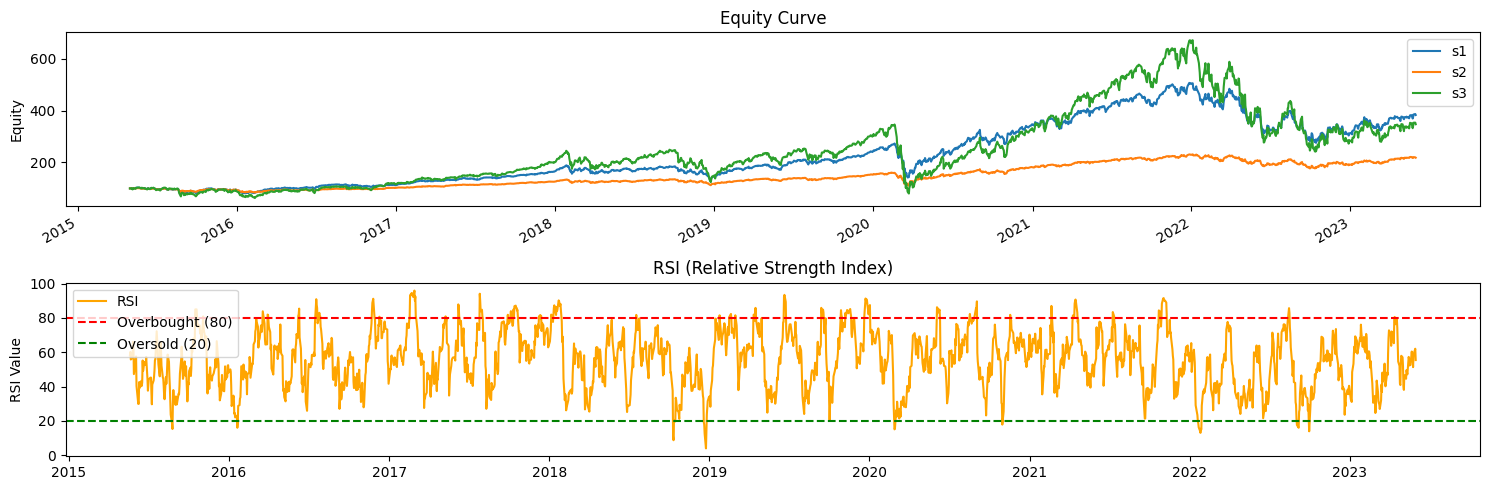

In [6]:
import matplotlib.pyplot as plt

# Assuming `res` is your equity curve DataFrame and `rsi` is your RSI Series
# First let's see an equity curve
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot equity curve
res.plot(ax=ax1)
ax1.set_title('Equity Curve')
ax1.set_ylabel('Equity')

# Plot RSI
ax2.plot(rsi.index, rsi, label='RSI', color='orange')
ax2.axhline(80, linestyle='--', color='red', label='Overbought (80)')
ax2.axhline(20, linestyle='--', color='green', label='Oversold (20)')
ax2.set_title('RSI (Relative Strength Index)')
ax2.set_ylabel('RSI Value')
ax2.legend()

# Improve layout
plt.tight_layout()
plt.show()


In [22]:
from tqdm import tqdm
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.offsets import BDay
import bt

startDate = '2015-05-01'
endDate = '2023-06-01'
data = bt.get('ioo', start=startDate, end=endDate)

def calculate_rsi(data, window=14):
    if isinstance(data, pd.DataFrame):
        # Assuming 'close' is the relevant column in your DataFrame
        price_data = data['ioo']  # Adjust this based on the actual column name
    elif isinstance(data, pd.Series):
        price_data = data
    else:
        raise ValueError("Input must be a DataFrame or Series.")

    delta = price_data.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    if rsi[-1] == np.NaN:
        rsi[-1] = 50

    return rsi

rsi = calculate_rsi(data)

# Create the strategy
s1 = bt.Strategy('s1', [bt.algos.RunMonthly(),
                       bt.algos.SelectWhere(rsi < 20),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

s2 = bt.Strategy('s2', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

# Create the backtest
test = bt.Backtest(s1, data)
test2 = bt.Backtest(s2, data)

# Run the backtest
res = bt.run(test, test2)

# Plot the results
res.plot()

  0%|          | 0/2 [00:00<?, ?it/s]


TypeError: unhashable type: 'Series'